In [2]:
import cv2
import os
import numpy as np
from pathlib import Path

def process_deepliif_mosaics(input_folder, output_base):
    # Crear carpetas de salida
    he_path = os.path.join(output_base, 'train_A')  # Entrada (H&E)
    ihc_path = os.path.join(output_base, 'train_B') # Objetivo (IHC)

    for p in [he_path, ihc_path]:
        os.makedirs(p, exist_ok=True)

    # Listar archivos (6.png, 6_0.png, etc.)
    valid_extensions = ('.png', '.jpg', '.jpeg')
    images = [f for f in os.listdir(input_folder) if f.lower().endswith(valid_extensions)]

    print(f"Procesando {len(images)} imágenes...")

    for img_name in images:
        img_path = os.path.join(input_folder, img_name)
        full_img = cv2.imread(img_path)

        if full_img is None: continue

        # En DeepLIIF, cada panel es cuadrado (usualmente 512x512)
        # La imagen completa tiene un ancho de 6 veces el alto
        height, width, _ = full_img.shape
        panel_width = width // 6

        # Extraer Panel 1 (IHC - Target) y Panel 2 (H&E - Input)
        ihc_real = full_img[:, 0:panel_width]
        he_original = full_img[:, panel_width:panel_width*2]

        # Guardar con el mismo nombre para mantener la pareja
        cv2.imwrite(os.path.join(ihc_path, img_name), ihc_real)
        cv2.imwrite(os.path.join(he_path, img_name), he_original)

    print("¡Proceso completado! Data lista para el Dataloader.")

# Configuración de rutas
dataset_path = "D:/job/TESIS/data/BC-DeepLIIF_Training_Set"
output_dir = "D:/job/TESIS/processed_data"

process_deepliif_mosaics(dataset_path, output_dir)

Procesando 385 imágenes...
¡Proceso completado! Data lista para el Dataloader.


In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import cv2
import os
from PIL import Image

class IHC_Benchmarking_Dataset(Dataset):
    def __init__(self, path_A, path_B, transform=None):
        self.path_A = path_A # H&E
        self.path_B = path_B # IHC Real
        self.images = sorted(os.listdir(path_A))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        # Cargar imágenes con PIL para compatibilidad con Transforms de PyTorch
        img_A = Image.open(os.path.join(self.path_A, img_name)).convert("RGB")
        img_B = Image.open(os.path.join(self.path_B, img_name)).convert("RGB")

        if self.transform:
            img_A = self.transform(img_A)
            img_B = self.transform(img_B)

        return img_A, img_B, img_name

# Configuración de Rutas
PATH_A = r"D:\job\TESIS\processed_data\train_A"
PATH_B = r"D:\job\TESIS\processed_data\train_B"

# Transformaciones estándar para Benchmarking (256x256 para rapidez)
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = IHC_Benchmarking_Dataset(PATH_A, PATH_B, transform=transform)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

In [8]:
import torch.nn as nn

class UNetGenerator(nn.Module):
    def __init__(self):
        super(UNetGenerator, self).__init__()
        # Encoder simple para benchmarking
        self.down1 = nn.Sequential(nn.Conv2d(3, 64, 4, 2, 1), nn.LeakyReLU(0.2))
        self.down2 = nn.Sequential(nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2))
        self.down3 = nn.Sequential(nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2))

        # Decoder
        self.up1 = nn.Sequential(nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU())
        self.up2 = nn.Sequential(nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU())
        self.up3 = nn.Sequential(nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Tanh())

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        u1 = self.up1(d3)
        u2 = self.up2(u1)
        return self.up3(u2)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_pix2pix = UNetGenerator().to(device)
optimizer = torch.optim.Adam(model_pix2pix.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion_L1 = nn.L1Loss()

epochs = 20 # Para benchmarking inicial basta con 20
print(f"Iniciando entrenamiento en {device}...")

for epoch in range(epochs):
    epoch_loss = 0
    for i, (real_A, real_B, _) in enumerate(dataloader):
        real_A, real_B = real_A.to(device), real_B.to(device)

        # Generar imagen sintética
        fake_B = model_pix2pix(real_A)

        # Calcular pérdida
        loss = criterion_L1(fake_B, real_B)

        # Optimizar
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] - Loss L1: {epoch_loss/len(dataloader):.4f}")

# Guardar Modelo 1
torch.save(model_pix2pix.state_dict(), "pix2pix_benchmarking.pth")

Iniciando entrenamiento en cuda...
Epoch [1/20] - Loss L1: 0.2243
Epoch [2/20] - Loss L1: 0.1873
Epoch [3/20] - Loss L1: 0.1780
Epoch [4/20] - Loss L1: 0.1711
Epoch [5/20] - Loss L1: 0.1695
Epoch [6/20] - Loss L1: 0.1676
Epoch [7/20] - Loss L1: 0.1638
Epoch [8/20] - Loss L1: 0.1615
Epoch [9/20] - Loss L1: 0.1588
Epoch [10/20] - Loss L1: 0.1563
Epoch [11/20] - Loss L1: 0.1529
Epoch [12/20] - Loss L1: 0.1518
Epoch [13/20] - Loss L1: 0.1519
Epoch [14/20] - Loss L1: 0.1496
Epoch [15/20] - Loss L1: 0.1480
Epoch [16/20] - Loss L1: 0.1512
Epoch [17/20] - Loss L1: 0.1467
Epoch [18/20] - Loss L1: 0.1461
Epoch [19/20] - Loss L1: 0.1437
Epoch [20/20] - Loss L1: 0.1428


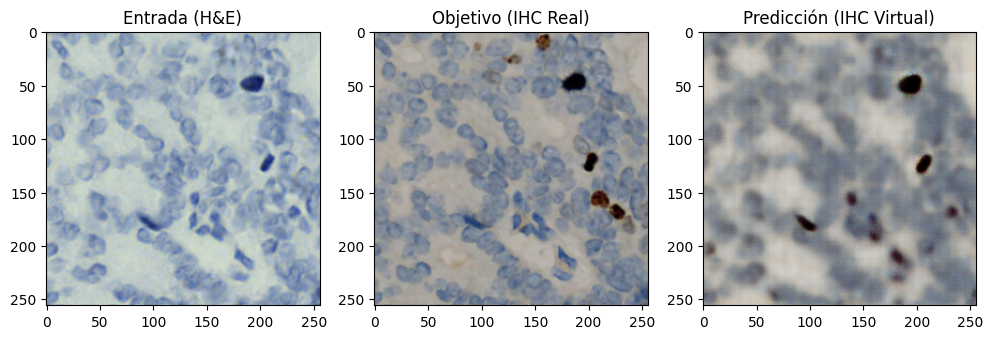

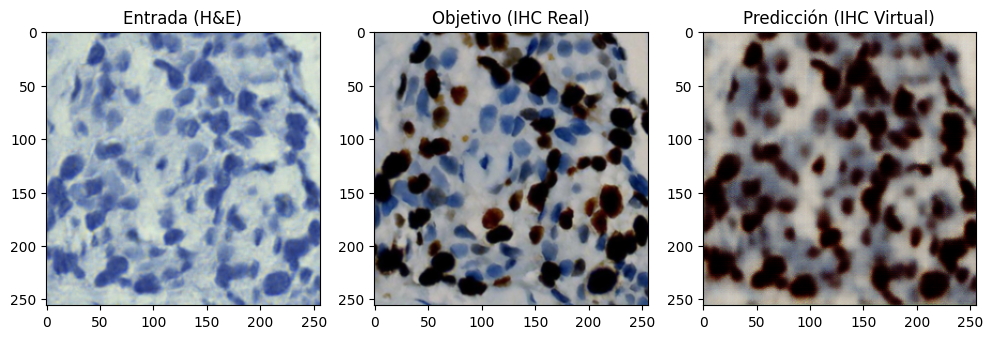

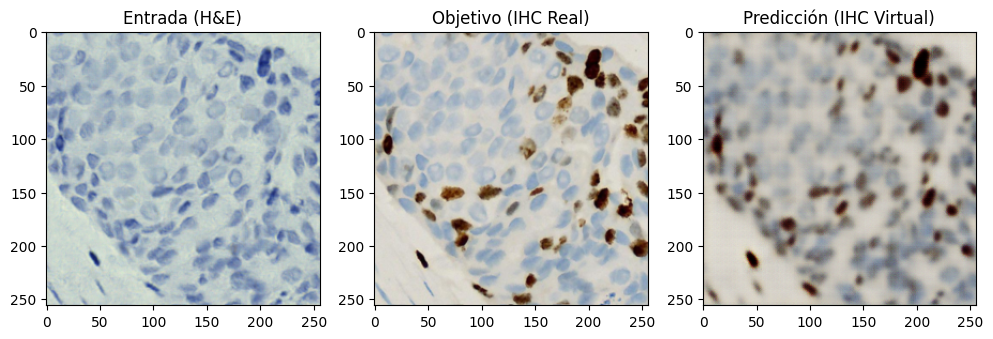

In [10]:
import torch
import matplotlib.pyplot as plt

def visualize_results(model, dataloader, device, num_samples=3):
    model.eval()
    with torch.no_grad():
        inputs, targets, names = next(iter(dataloader))
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)

        for i in range(num_samples):
            plt.figure(figsize=(12, 4))
            # H&E Original
            plt.subplot(1, 3, 1)
            plt.title("Entrada (H&E)")
            plt.imshow(inputs[i].cpu().permute(1, 2, 0) * 0.5 + 0.5)
            # IHC Real (Ground Truth)
            plt.subplot(1, 3, 2)
            plt.title("Objetivo (IHC Real)")
            plt.imshow(targets[i].cpu().permute(1, 2, 0) * 0.5 + 0.5)
            # IHC Virtual (Predicción)
            plt.subplot(1, 3, 3)
            plt.title("Predicción (IHC Virtual)")
            plt.imshow(outputs[i].cpu().permute(1, 2, 0) * 0.5 + 0.5)
            plt.show()

visualize_results(model_pix2pix, dataloader, device)

In [11]:
import torch.nn as nn
import torch

class UNetSegmenter(nn.Module):
    def __init__(self):
        super(UNetSegmenter, self).__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )

        self.enc1 = conv_block(3, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = conv_block(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = conv_block(128, 64)

        self.final = nn.Conv2d(64, 3, kernel_size=1) # Salida RGB para comparar

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        bn = self.bottleneck(self.pool(e3))

        d3 = self.dec3(torch.cat([self.up3(bn), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return torch.tanh(self.final(d1))

In [12]:
model_unet = UNetSegmenter().to(device)
optimizer = torch.optim.Adam(model_unet.parameters(), lr=0.0001)
criterion = nn.MSELoss() # Cambiamos a MSE para ver si mejora la definición de bordes

print("Iniciando entrenamiento de Modelo 2 (U-Net)...")
for epoch in range(20):
    epoch_loss = 0
    for real_A, real_B, _ in dataloader:
        real_A, real_B = real_A.to(device), real_B.to(device)

        preds = model_unet(real_A)
        loss = criterion(preds, real_B)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1}/20] - U-Net Loss: {epoch_loss/len(dataloader):.4f}")

torch.save(model_unet.state_dict(), "unet_benchmarking.pth")

Iniciando entrenamiento de Modelo 2 (U-Net)...
Epoch [1/20] - U-Net Loss: 0.0970
Epoch [2/20] - U-Net Loss: 0.0726
Epoch [3/20] - U-Net Loss: 0.0632
Epoch [4/20] - U-Net Loss: 0.0611
Epoch [5/20] - U-Net Loss: 0.0567
Epoch [6/20] - U-Net Loss: 0.0573
Epoch [7/20] - U-Net Loss: 0.0525
Epoch [8/20] - U-Net Loss: 0.0496
Epoch [9/20] - U-Net Loss: 0.0482
Epoch [10/20] - U-Net Loss: 0.0473
Epoch [11/20] - U-Net Loss: 0.0450
Epoch [12/20] - U-Net Loss: 0.0440
Epoch [13/20] - U-Net Loss: 0.0434
Epoch [14/20] - U-Net Loss: 0.0434
Epoch [15/20] - U-Net Loss: 0.0396
Epoch [16/20] - U-Net Loss: 0.0389
Epoch [17/20] - U-Net Loss: 0.0425
Epoch [18/20] - U-Net Loss: 0.0379
Epoch [19/20] - U-Net Loss: 0.0369
Epoch [20/20] - U-Net Loss: 0.0362


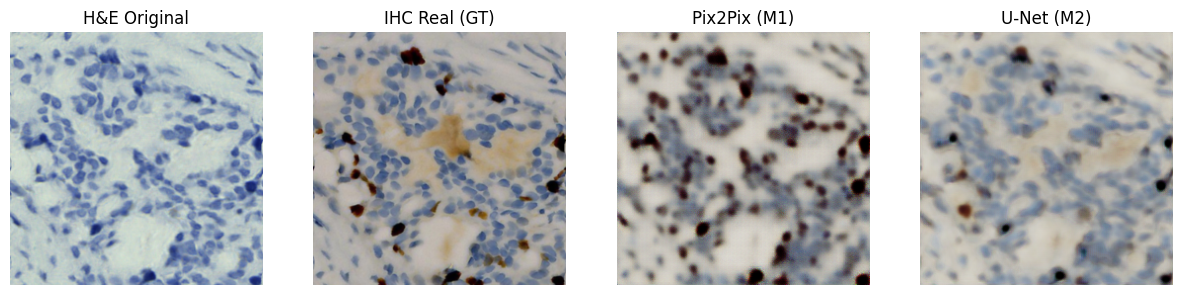


--- RESULTADOS DEL BENCHMARKING ---
Pix2Pix -> Dice: 0.3064 | SSIM: 0.4754
UNet -> Dice: 0.3670 | SSIM: 0.5498


In [13]:
import torch
import numpy as np
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

def dice_coeff(pred, target, threshold=0.5):
    # Convertir a binario para medir solapamiento celular
    p = (pred > threshold).float()
    t = (target > threshold).float()
    inter = torch.sum(p * t)
    return (2.0 * inter) / (torch.sum(p) + torch.sum(t) + 1e-8)

def run_versus(model1, model2, dataloader, device):
    model1.eval()
    model2.eval()

    metrics = {"Pix2Pix": {"dice": [], "ssim": []}, "UNet": {"dice": [], "ssim": []}}

    with torch.no_grad():
        inputs, targets, _ = next(iter(dataloader))
        inputs, targets = inputs.to(device), targets.to(device)

        out1 = model1(inputs)
        out2 = model2(inputs)

        # Procesar métricas para el primer batch
        for i in range(len(inputs)):
            # Convertir a numpy para SSIM
            t_np = targets[i].cpu().permute(1,2,0).numpy()
            o1_np = out1[i].cpu().permute(1,2,0).numpy()
            o2_np = out2[i].cpu().permute(1,2,0).numpy()

            # Calcular SSIM (Similitud Estructural)
            metrics["Pix2Pix"]["ssim"].append(ssim(t_np, o1_np, channel_axis=2, data_range=2))
            metrics["UNet"]["ssim"].append(ssim(t_np, o2_np, channel_axis=2, data_range=2))

            # Calcular Dice (Solapamiento)
            metrics["Pix2Pix"]["dice"].append(dice_coeff(out1[i], targets[i]).item())
            metrics["UNet"]["dice"].append(dice_coeff(out2[i], targets[i]).item())

    # --- Visualización Comparativa ---
    plt.figure(figsize=(15, 10))
    titles = ["H&E Original", "IHC Real (GT)", "Pix2Pix (M1)", "U-Net (M2)"]
    imgs = [inputs[0], targets[0], out1[0], out2[0]]

    for i in range(4):
        plt.subplot(1, 4, i+1)
        plt.title(titles[i])
        plt.imshow(imgs[i].cpu().permute(1, 2, 0) * 0.5 + 0.5)
        plt.axis('off')
    plt.show()

    print("\n--- RESULTADOS DEL BENCHMARKING ---")
    for mod in ["Pix2Pix", "UNet"]:
        print(f"{mod} -> Dice: {np.mean(metrics[mod]['dice']):.4f} | SSIM: {np.mean(metrics[mod]['ssim']):.4f}")

# Cargar modelos y correr
# model_pix2pix.load_state_dict(torch.load("pix2pix_benchmarking.pth"))
# model_unet.load_state_dict(torch.load("unet_benchmarking.pth"))
run_versus(model_pix2pix, model_unet, dataloader, device)